In [42]:
import sys
from pathlib import Path

In [41]:
project_root = Path().resolve().parent  
project_root

PosixPath('/Users/zhigangyu/Documents/Project Z')

In [16]:
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

In [1]:
import numpy as np
np.random.seed(42)

In [2]:
from importlib import reload

In [17]:
import run

In [18]:
import pandas as pd
from tqdm import tqdm

In [19]:
from src import data_broker
from src import calendar_iterator
from src import strategy_selector_1
from src import filter_optimizer_1
from src import performance_evaluator_1,performance_evaluator
from src import data_broker
from src import statioinary_bootstrap

In [20]:
# params
initial_capital= 100000.0
transaction_cost_pct=.001
forward_month=6
allocation_type='equal'

In [21]:
tickers=['SPY','QQQ','QQQE','IWM','XSW','XLY','XLV','XLU','XLRE','XLP','XLK','XLI','XLF','XLE','XLC','XLB','XBI','VXX']
bench_ticker1=['SPY']
bench_ticker2=['QQQ']

In [22]:
broker = data_broker.DataBroker(tickers=tickers, start_date="2022-01-01", end_date="2026-04-01")
universe_data = broker.fetch_universe_data()

[*********************100%***********************]  18 of 18 completed


In [24]:
universe_data['price'].head()

,SPY,QQQ,QQQE,IWM,XSW,XLY,XLV,XLU,XLRE,XLP,XLK,XLI,XLF,XLE,XLC,XLB,XBI,VXX
Date,,,,,,,,,,,,,,,,,,
2022-01-03,449.486450,390.756775,82.224892,213.010727,165.429657,101.215271,129.536423,30.957333,44.042484,68.449989,84.835770,97.988998,36.579292,24.452921,74.578583,40.881115,114.711288,286.399994
2022-01-04,449.335968,385.688477,81.230621,212.689255,162.742630,100.599251,127.827148,30.861235,43.870876,68.911644,83.936760,99.959244,37.541668,25.299070,74.416496,41.383957,110.657051,286.079987
2022-01-05,440.707642,373.839691,78.962151,205.485550,155.557404,97.884903,126.916718,30.843756,42.446556,68.849510,81.355728,99.006805,37.106743,25.294792,72.547745,41.379379,104.565742,308.640015
2022-01-06,440.293671,373.577026,79.290344,206.657791,155.268799,97.629852,125.448929,30.524872,42.498032,68.663063,80.944893,99.464325,37.652706,25.858898,72.871925,40.858261,104.535927,310.079987
2022-01-07,438.552979,369.530121,78.440887,204.266052,154.203964,96.003151,124.807945,30.756397,42.274944,68.734100,80.200539,99.436325,38.096882,26.213596,72.881454,40.821701,102.339867,301.119995


In [25]:
broker1 = data_broker.DataBroker(tickers=bench_ticker1, start_date="2022-01-01", end_date="2026-04-01")
bench_data1 = broker1.fetch_universe_data()

broker2 = data_broker.DataBroker(tickers=bench_ticker2, start_date="2022-01-01", end_date="2026-04-01")
bench_data2 = broker2.fetch_universe_data()

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


In [26]:
# Anchor prices to seed the start of our synthetic worlds
anchor_prices = universe_data['price'].iloc[0].to_dict()

In [27]:
strategies={
    'info':strategy_selector_1.InformationDiscreteMomentum(lookback_days=252),
    'info_std2':strategy_selector_1.InformationDiscreteWithExhaustion(lookback_days=252, z_threshold=2),
    'info_std3':strategy_selector_1.InformationDiscreteWithExhaustion(lookback_days=252, z_threshold=3),
    'adj_mom':strategy_selector_1.RiskAdjustedMomentum(lookback_days=252),
    'raw_mom':strategy_selector_1.MomentumStrategy(lookback_days=252)
}

In [28]:
portfolio_filter = filter_optimizer_1.VolumeWeightFilter(top_percent=0.40, min_dollar_volume=10_000_000, allocation_type=allocation_type)

# run simulation

In [29]:
NUM_SIMULATIONS = 10

In [30]:
# Initialize the engine
data_for_boot=bench_data1 #universe_data # bench_data1,bench_data2


engine = statioinary_bootstrap.VectorizedBootstrapEngine(data_for_boot, expected_block_size=21)

In [32]:
# Instantly generates a 3D NumPy Tensor: Shape (1000, Num_Days, 4)
synthetic_data_cube = engine.generate_all_worlds(
    num_simulations=NUM_SIMULATIONS, 
    start_prices=anchor_prices
)


In [33]:
# Unpack tensors from the engine output
prices_3d = synthetic_data_cube['price_tensor']
volume_3d = synthetic_data_cube['volume_tensor']

In [35]:
strategies.keys()

dict_keys(['info', 'info_std2', 'info_std3', 'adj_mom', 'raw_mom'])

In [36]:
strategy=strategies['adj_mom']
# strategy=dummy_strategy

In [37]:
# Run the Macro Orchestrator validation pass
df_nav_list=[]
sim_collector=run.SimulationCollector()

for sim_id in tqdm(range(NUM_SIMULATIONS)):
    
    # Pack the 3D slices into clean 2D DataFrames with the ORIGINAL calendar dates index
    world_data_dict = {
        'price': pd.DataFrame(prices_3d[sim_id, :, :], index=engine.dates_index, columns=engine.tickers),
        'volume': pd.DataFrame(volume_3d[sim_id, :, :], index=engine.dates_index, columns=engine.tickers)
    }
    
    # --- Meso Layer Hand-off ---
    # Now your downstream modules get the exact layout they expect, completely synced
    calendar = calendar_iterator.CalendarIterator(world_data_dict, interval="ME")
    rebalance_dates = calendar.generate_rebalance_dates()

    break
    evaluator= run.run(world_data_dict,rebalance_dates, calendar,strategy,portfolio_filter)
    df_nav,report=run.get_df_nav(evaluator)
    df_nav_list.append(df_nav)
    df_nav_list.append({'df_nav':df_nav,'report':report})
    sim_collector.collect(report)

  0%|                                                                                                                                                                                                        | 0/10 [00:00<?, ?it/s]


In [123]:
df_reports=sim_collector.to_dataframe()

In [124]:
df_nav_bench1=df_nav_list
df_reports_bench1=df_reports

In [125]:
df_reports_bench1.mean()

is_return        9.466725
oos_return      11.182650
is_vol          18.969225
oos_vol         18.941400
is_sharpe        0.314525
oos_sharpe       0.523750
is_sortino       0.431225
oos_sortino      0.846175
is_drawdown    -25.999575
oos_drawdown   -12.361925
dtype: float64

In [44]:
df_reports_adj_mom.mean()

is_return        7.37810
oos_return      10.94457
is_vol          16.45248
oos_vol         16.71404
is_sharpe        0.20393
oos_sharpe       0.47561
is_sortino       0.28931
oos_sortino      0.80169
is_drawdown    -23.01864
oos_drawdown   -10.69510
dtype: float64

In [45]:
df_reports_info2.mean()

is_return        7.21070
oos_return       9.70800
is_vol          16.92965
oos_vol         16.93391
is_sharpe        0.18821
oos_sharpe       0.41708
is_sortino       0.26826
oos_sortino      0.71649
is_drawdown    -23.25514
oos_drawdown   -11.21184
dtype: float64

# save

In [126]:
import pickle

In [127]:
with open('df_nav_bench1.pickle','wb+') as f:
    pickle.dump(df_nav_list,f)

In [128]:
df_reports.to_csv('report_bench1.csv',index=False)

In [129]:
len(df_nav_list)

800

# load

In [28]:
with open('df_nav_info_std2.pickle','rb+') as f:
    df_nav_list_info2=f.read()

In [31]:
df_reports_info2=pd.read_csv('report_info_std2.csv')

In [84]:
df_reports=sim_collector.to_dataframe()
df_reports.mean()

is_return        7.21070
oos_return       9.70800
is_vol          16.92965
oos_vol         16.93391
is_sharpe        0.18821
oos_sharpe       0.41708
is_sortino       0.26826
oos_sortino      0.71649
is_drawdown    -23.25514
oos_drawdown   -11.21184
dtype: float64

In [85]:
run.display_report(report)

,In-Sample (Historical),Forward Performance (OOS)
Metric Profile,,
Annualized Return,3.42%,17.85%
Annualized Volatility,17.7%,14.34%
Sharpe Ratio,-0.030000,0.970000
Sortino Ratio,-0.040000,1.340000
Max Drawdown,-22.17%,-8.76%


In [83]:
run.analyze_metric_difference(df_reports['is_return'].tolist(),df_reports['oos_return'].tolist())

        STATISTICAL SIGNIFICANCE REPORT        
Long-Term (IS)       | Mean:   7.21% | StdDev:   7.73%
Mid-Term (OOS)       | Mean:   9.71% | StdDev:  23.94%
--------------------------------------------------
Absolute Difference: 2.50%
T-Statistic:        -3.1396
P-Value:            1.7331e-03
--------------------------------------------------
Conclusion: STATISTICALLY SIGNIFICANT
-> The difference is real. The strategy performed significantly
   differently in the Mid-Term (OOS) period than the Long-Term (IS) period.


{'t_statistic': np.float64(-3.1395656803370753),
 'p_value': np.float64(0.0017331030398297597),
 'significant': np.True_}

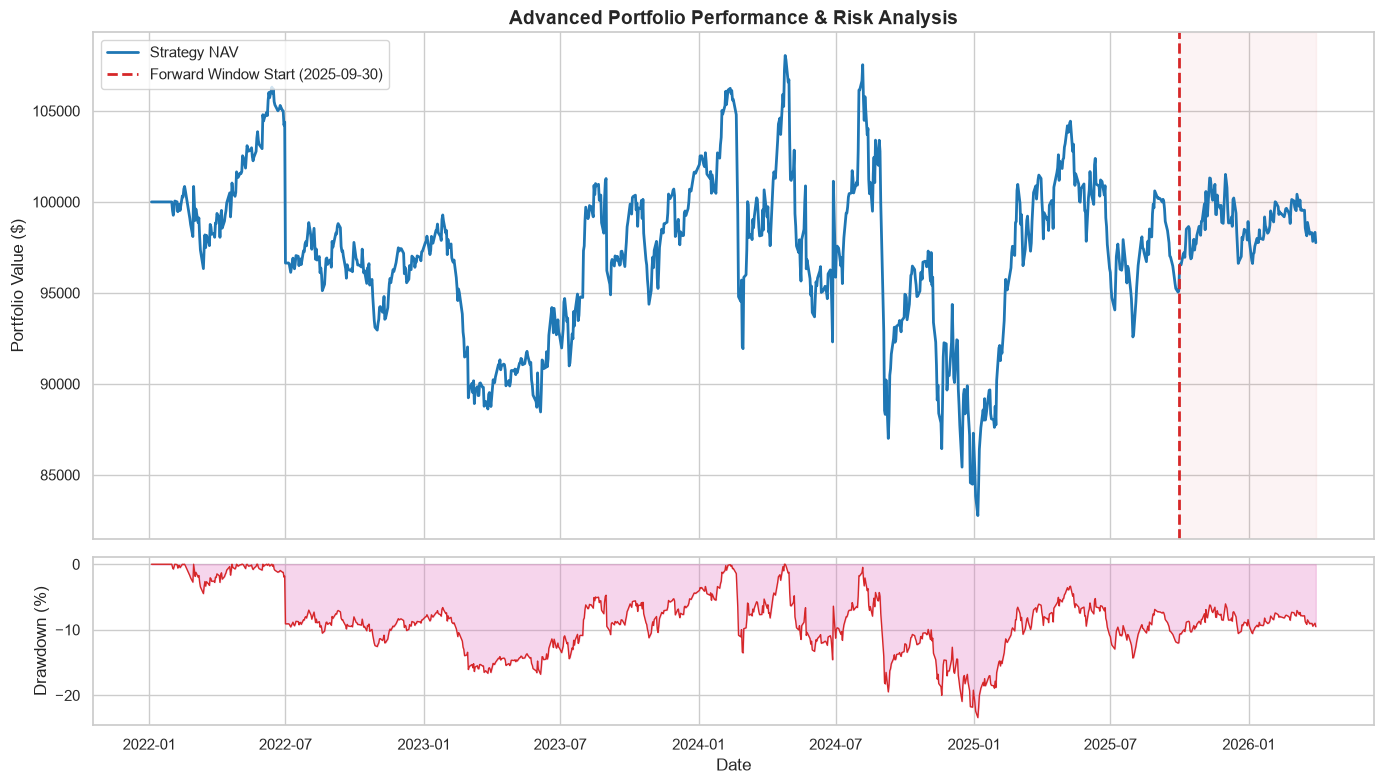

In [62]:
run.plot_nav_charts(df_nav)

NameError: name 'df_navs' is not defined

In [ ]:
df_nav

In [12]:
# --- Macro Orchestrator Loop ---
bootstrap_engine = statioinary_bootstrap.StationaryBootstrapEngine(mock_returns, expected_block_size=21)

In [13]:
bootstrap_engine

In [14]:
NUM_SIMULATIONS = 1000
all_simulation_results = []

print(f"Launching {NUM_SIMULATIONS} synthetic world simulations...")

Launching 1000 synthetic world simulations...


In [15]:
for i in range(NUM_SIMULATIONS):
    # Module A generates a clean, gap-free historical path
    synthetic_market_data = bootstrap_engine.generate_synthetic_path(start_prices=current_market_prices)
    
    # --- Meso Layer Hand-off ---
    # your_strategy_module.run(synthetic_market_data)
    # your_filter_module.run(...)
    # metrics = your_evaluation_module.calculate_performance()
    
    # Dummy placeholder for evaluation metrics per run
    simulated_sharpe = np.random.normal(0.8, 0.2) 
    all_simulation_results.append(simulated_sharpe)

In [16]:
# --- Aggregated Meta-Analytics ---
mean_of_means_sharpe = np.mean(all_simulation_results)
sharpe_variance = np.std(all_simulation_results)

print("\n--- Meta-Analytics Dashboard Results ---")
print(f"Expected Strategy Sharpe (Mean of Means): {mean_of_means_sharpe:.2f}")
print(f"Strategy Stability (Standard Deviation):  {sharpe_variance:.2f}")
print(f"Probability of Alpha Falsification (Sharpe < 0): {np.mean(np.array(all_simulation_results) < 0) * 100:.1f}%")


--- Meta-Analytics Dashboard Results ---
Expected Strategy Sharpe (Mean of Means): 0.80
Strategy Stability (Standard Deviation):  0.20
Probability of Alpha Falsification (Sharpe < 0): 0.0%
